# Problem Set 3

## Problem 1

### Part c: First-Visit Monte Carlo

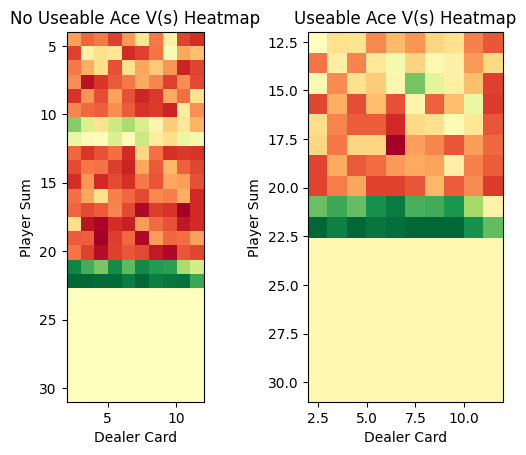

In [52]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np


# First visit fixed Monte Carlo Agent
class FirstVisitMC:
    def __init__(self):
        self.V = {}
        self.alpha = 0.1

    # Fixed policy "stick if sum >= 20, otherwise hit"
    def policy(self, obs):
        (sum, _, _) = obs
        if sum >= 20:
            return 0 # stick / stand
        else:
            return 1 # hit

    # Generates an episode of training then updates
    def train_episode(self, env):
        # Simulate an episode
        obs, _ = env.reset()
        terminate = False
        r = []
        first_visit = {obs: 0}
        t = 1
        while not terminate:
            obs, reward, terminate, _, _ = env.step(self.policy(obs))
            r.append(reward)
            if not obs in first_visit:
                first_visit[obs] = t
            t += 1
        # Update V
        for state, t in first_visit.items():
            if not state in self.V:
                self.V[state] = 0
            G_t = sum(r[t:])
            self.V[state] += self.alpha * (G_t - self.V[state])

    # Plot V(s) as two heatmaps (useable ace true vs false)
    def plot_heatmaps(self):
        # valid sums are 4-20 (else terminal), dealer cards are 2-11
        # If we have a useable ace, then the sum can't be under 12
        heatmap_ace = np.zeros((18, 10))
        heatmap_not = np.zeros((26, 10))
        for (sum, dealer, ace), v in self.V.items():
            if ace:
                heatmap_ace[sum - 12, dealer - 2] = v
            else:
                heatmap_not[sum - 4, dealer - 2] = v

        fig, axs = plt.subplots(1, 2)

        axs[0].imshow(heatmap_not, cmap='RdYlGn', interpolation='none', extent=[2, 12, 31, 4])
        axs[0].set_title("No Useable Ace V(s) Heatmap")
        axs[0].set_xlabel("Dealer Card")
        axs[0].set_ylabel("Player Sum")

        axs[1].imshow(heatmap_ace, cmap='RdYlGn', interpolation='none', extent=[2, 12, 31, 12])
        axs[1].set_title("Useable Ace V(s) Heatmap")
        axs[1].set_xlabel("Dealer Card")
        axs[1].set_ylabel("Player Sum")
        plt.show()
            

# Create blackjack environment
env = gym.make("Blackjack-v1")

# Construct agent
agent = FirstVisitMC()

# Run for 500,000 episodes
for _ in range(int(5e5)):
    agent.train_episode(env)

# Display heatmaps
agent.plot_heatmaps()

### Part d: Monte Carlo control with ε-soft

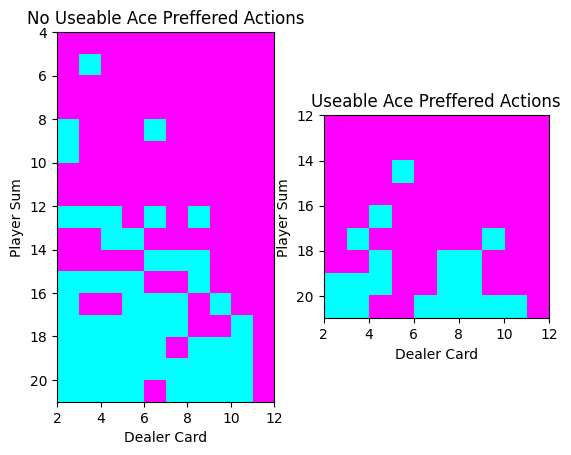

In [49]:
class EpsilonSoftMC:
    def __init__(self, epsilon=0.1):
        self.epsilon = epsilon
        self.Q = [{}, {}] # self.Q[action][state] -> value
        self.m = 2.0 # |A|
        self.alpha = 0.1

    # Returns the approximated q value for the given state & action,
    # with 0 being the default
    def get_q(self, state, action):
        if not state in self.Q[action]:
            self.Q[action][state] = 0
        return self.Q[action][state]

    # Returns the probability of taking the action given the 'optimal' action for the current state
    def prob(self, action, optimal):
        return (self.epsilon / self.m) + (1.0 - self.epsilon if action == optimal else 0.0)

    # Returns "optimal" action (ignoring epsilon soft, just maximizing Q)
    def learned_policy(self, state):
        stand_q = self.get_q(state, 0)
        hit_q = self.get_q(state, 1)
        return 0 if stand_q > hit_q else 1

    # Applies the learned Q values as a policy using epsilon soft
    def policy(self, state):
        optimal = self.learned_policy(state)
        return np.random.choice(2, p=[self.prob(0, optimal), self.prob(1, optimal)])

    # Generates an episode of training then updates
    def train_episode(self, env):
        # Simulate an episode
        state, _ = env.reset()
        terminate = False
        r = []
        first_visit = {}
        t = 0
        while not terminate:
            action = self.policy(state)
            state, reward, terminate, _, _ = env.step(action)
            r.append(reward)
            if not (state, action) in first_visit:
                first_visit[(state, action)] = t
            t += 1
        # Update Q
        for (state, action), t in first_visit.items():
            if not state in self.Q[action]:
                self.Q[action][state] = 0
            G_t = sum(r[t:])
            self.Q[action][state] += self.alpha * (G_t - self.Q[action][state])

    # Plots the learned policy
    def plot_policy(self):
        # valid sums are 4-20 (otherwise won or bust), dealer cards are 2-11
        # If we have a useable ace, then the sum is constrained to (12-20)
        policy_ace = np.zeros((9, 10))
        policy_not = np.zeros((17, 10))

        for ace in range(2):
            for sum in range(12 if ace else 4, 21):
                for dealer in range(2, 12):
                    action = self.learned_policy((sum, dealer, ace))
                    if ace:
                        policy_ace[sum - 12, dealer - 2] = action
                    else:
                        policy_not[sum - 4, dealer - 2] = action

        fig, axs = plt.subplots(1, 2)

        axs[0].imshow(policy_not, cmap='cool', interpolation='none', extent=[2, 12, 21, 4])
        axs[0].set_title("No Useable Ace Preffered Actions")
        axs[0].set_xlabel("Dealer Card")
        axs[0].set_ylabel("Player Sum")

        axs[1].imshow(policy_ace, cmap='cool', interpolation='none', extent=[2, 12, 21, 12])
        axs[1].set_title("Useable Ace Preffered Actions")
        axs[1].set_xlabel("Dealer Card")
        axs[1].set_ylabel("Player Sum")
        plt.show()

    
        
# Construct agent
agent = EpsilonSoftMC()

# Run for 500,000 episodes
for _ in range(int(5e5)):
    agent.train_episode(env)

# Display policy
agent.plot_policy()

In the figure above, blue indicates stand/stick while pink indicates hit. 

A noticeable difference in this policy is that it will hit at 20 if the dealer is showing an ace, or if the dealer is showing a 7 and they have an ace to use. The policy also chooses to stand below 20 in many instances that appear to coincide with where a bust is likely (like at 18) or if the dealer has a low card (meaning their odds of wining without blackjack are higher)